In [1]:
!nvidia-smi

Sat Jun 27 04:24:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [3]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
import ultralytics

ultralytics.checks()

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="API_KEY")
project = rf.workspace("machine-train-ur3hn").project("skin-qfi4b")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to skin-1 in yolov8:: 100%|██████████| 1530/1530 [00:00<00:00, 10718.16it/s]


In [7]:
import os

for root,dirs,files in os.walk(dataset.location):
    print(root, len(files))

/content/skin-1 3
/content/skin-1/test 0
/content/skin-1/test/images 47
/content/skin-1/test/labels 47
/content/skin-1/valid 0
/content/skin-1/valid/images 99
/content/skin-1/valid/labels 99
/content/skin-1/train 0
/content/skin-1/train/images 613
/content/skin-1/train/labels 613


In [8]:
from pathlib import Path

train_path = Path(dataset.location)/"train"

images = list(train_path.glob("*"))

print("Training images:",len(images))

Training images: 2


Total images: 613


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

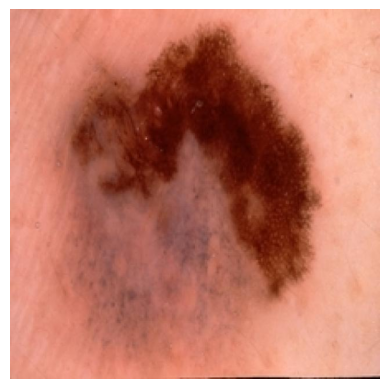

In [10]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt


image_folder="/content/skin-1/train/images"


# get all image files
images=[]

for file in os.listdir(image_folder):
    if file.endswith((".jpg",".jpeg",".png")):
        images.append(
            os.path.join(image_folder,file)
        )


print("Total images:",len(images))


# choose random image
img=random.choice(images)


plt.imshow(Image.open(img))
plt.axis("off")

## Dataset Preparation and Verification

The dataset is already available in YOLOv8 object detection format.
It contains images and corresponding bounding box annotations.

In [56]:
import os


dataset="/content/skin-1"


for split in ["train","valid","test"]:

    image_count = len(
        os.listdir(f"{dataset}/{split}/images")
    )

    label_count = len(
        os.listdir(f"{dataset}/{split}/labels")
    )


    print(split)
    print("Images:", image_count)
    print("Labels:", label_count)
    print("----------------")

train
Images: 613
Labels: 613
----------------
valid
Images: 99
Labels: 99
----------------
test
Images: 47
Labels: 47
----------------


In [55]:
import os

for root, dirs, files in os.walk("/content/skin-1"):

    if len(files) > 0:
        print(root, len(files))

/content/skin-1 3
/content/skin-1/test/images 47
/content/skin-1/test/labels 47
/content/skin-1/valid 1
/content/skin-1/valid/images 99
/content/skin-1/valid/labels 99
/content/skin-1/train 1
/content/skin-1/train/images 613
/content/skin-1/train/labels 613


In [43]:

import os

for root, dirs, files in os.walk("/content/runs"):
    for file in files:
        if file.endswith(".pt"):
            print(os.path.join(root,file))

/content/runs/detect/train-5/weights/last.pt
/content/runs/detect/train-5/weights/best.pt
/content/runs/classify/train/weights/last.pt
/content/runs/classify/train/weights/best.pt


## YOLOv8 Detection Model Training

In [36]:
import os

print(os.listdir("/content/skin-1"))

['test', 'README.dataset.txt', 'data.yaml', 'README.roboflow.txt', 'valid', 'train']


In [40]:
import os

print(os.listdir("runs"))

['detect', 'classify']


In [41]:
print(os.listdir("runs/detect"))

['train-5', 'train-2', 'train-3', 'train-4', 'train']


In [13]:
!pip install ultralytics
from ultralytics import YOLO

In [27]:
model = YOLO("yolov8n.pt")

In [46]:
from ultralytics import YOLO

model = YOLO("runs/detect/train-5/weights/best.pt")

print(model.task)

detect


YOLOv8n-cls is a lightweight pretrained classification model.
Transfer learning is used by fine tuning it on the skin dataset.

In [37]:

results = model.train(

    data="/content/skin-1/data.yaml",

    epochs=50,

    imgsz=640,

    batch=16,

    device=0

)

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/skin-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,

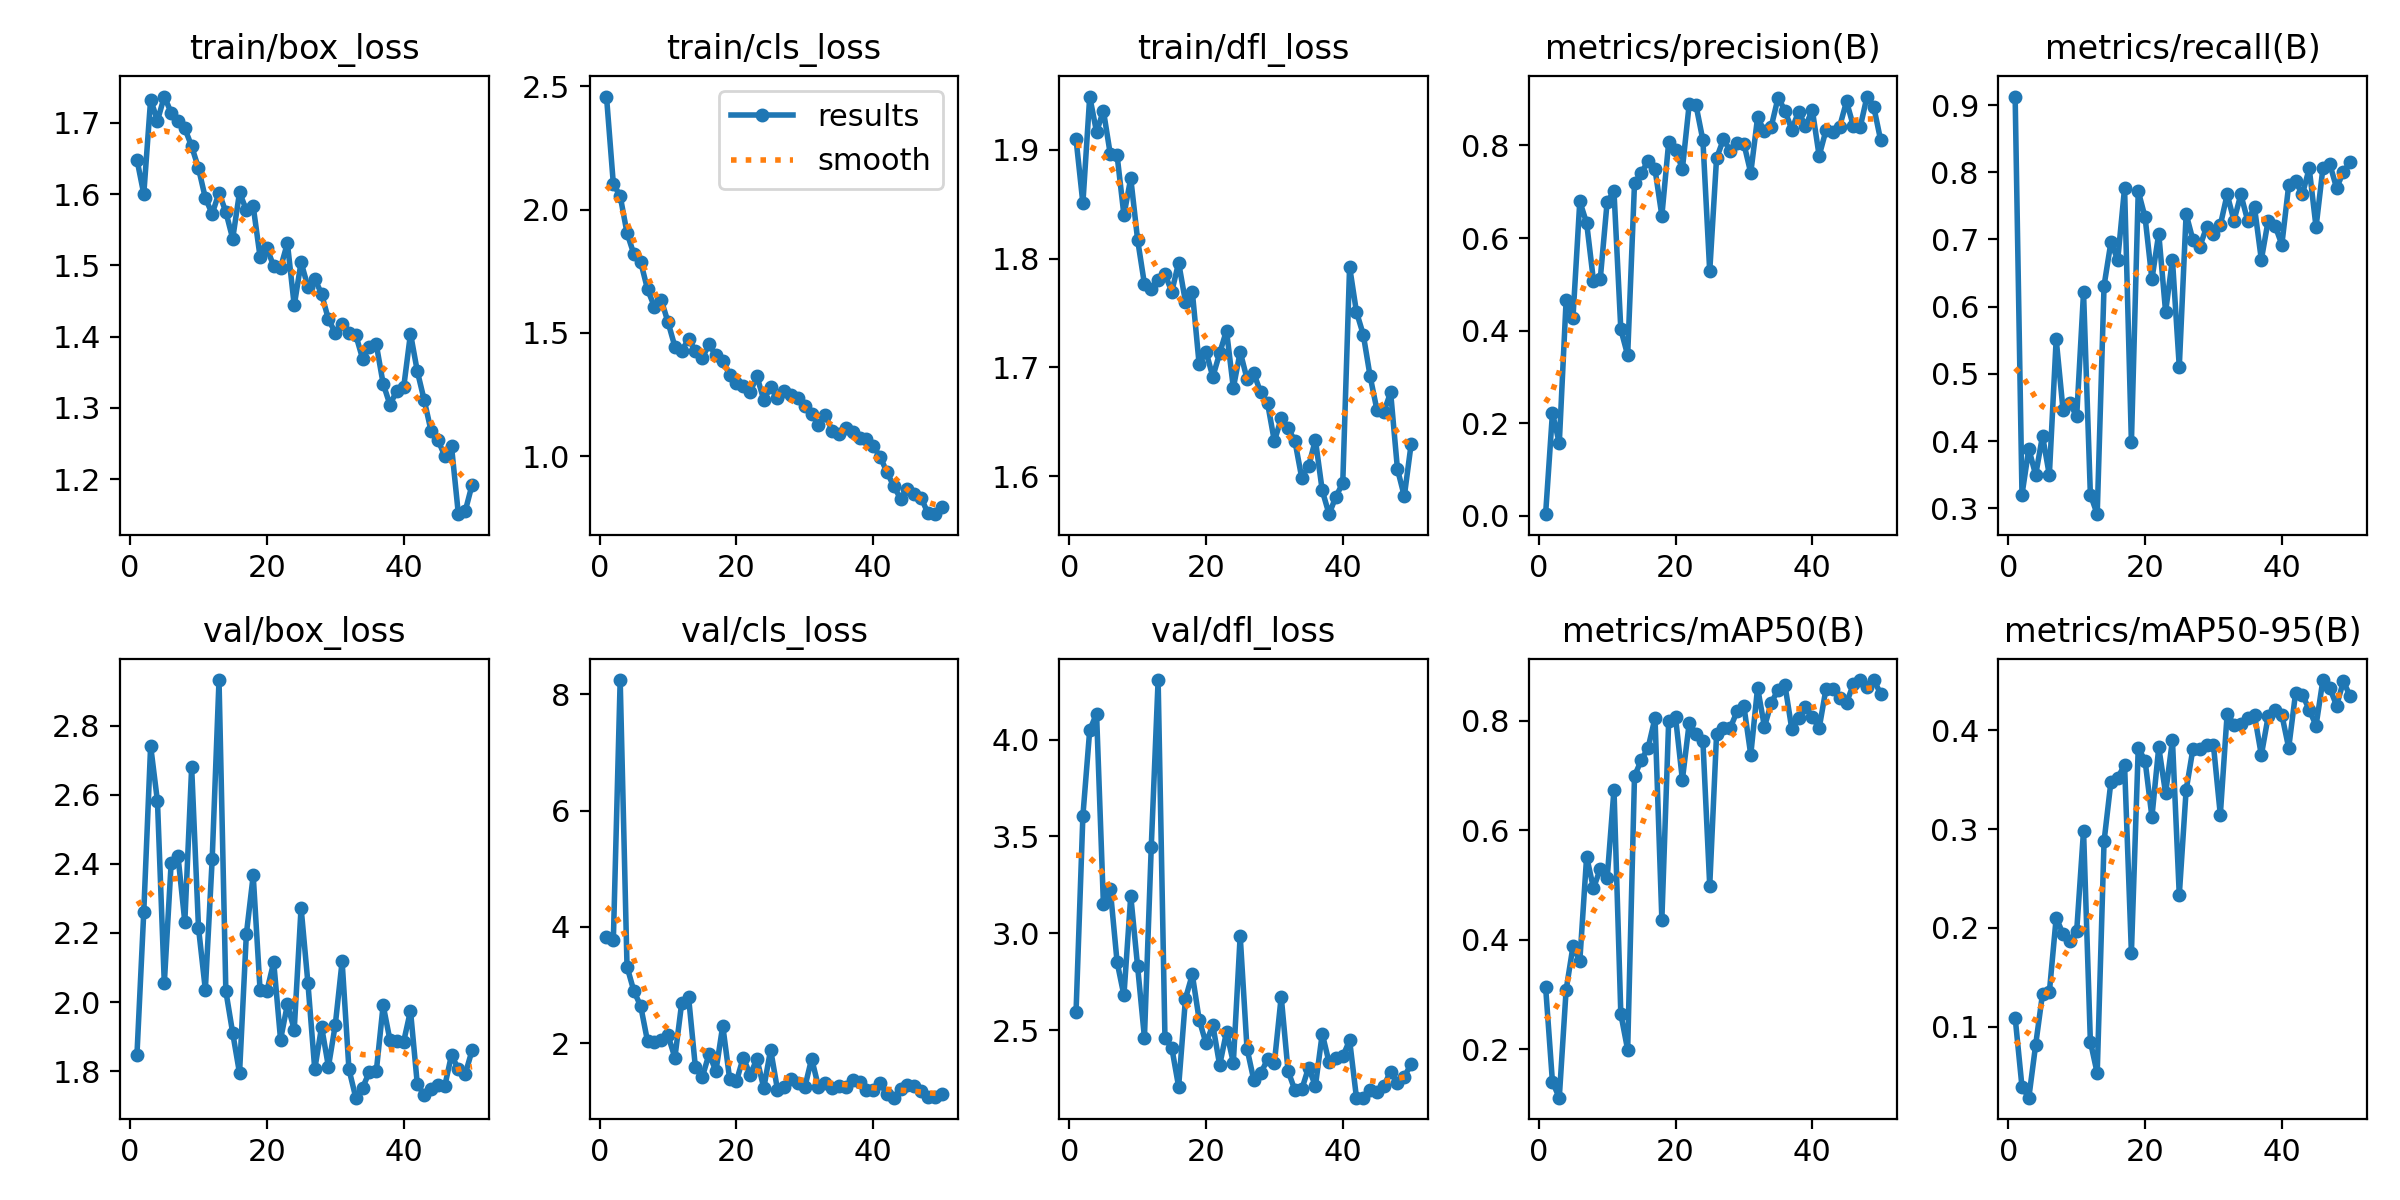

In [47]:
from IPython.display import Image

Image(
filename="runs/detect/train-5/results.png"
)

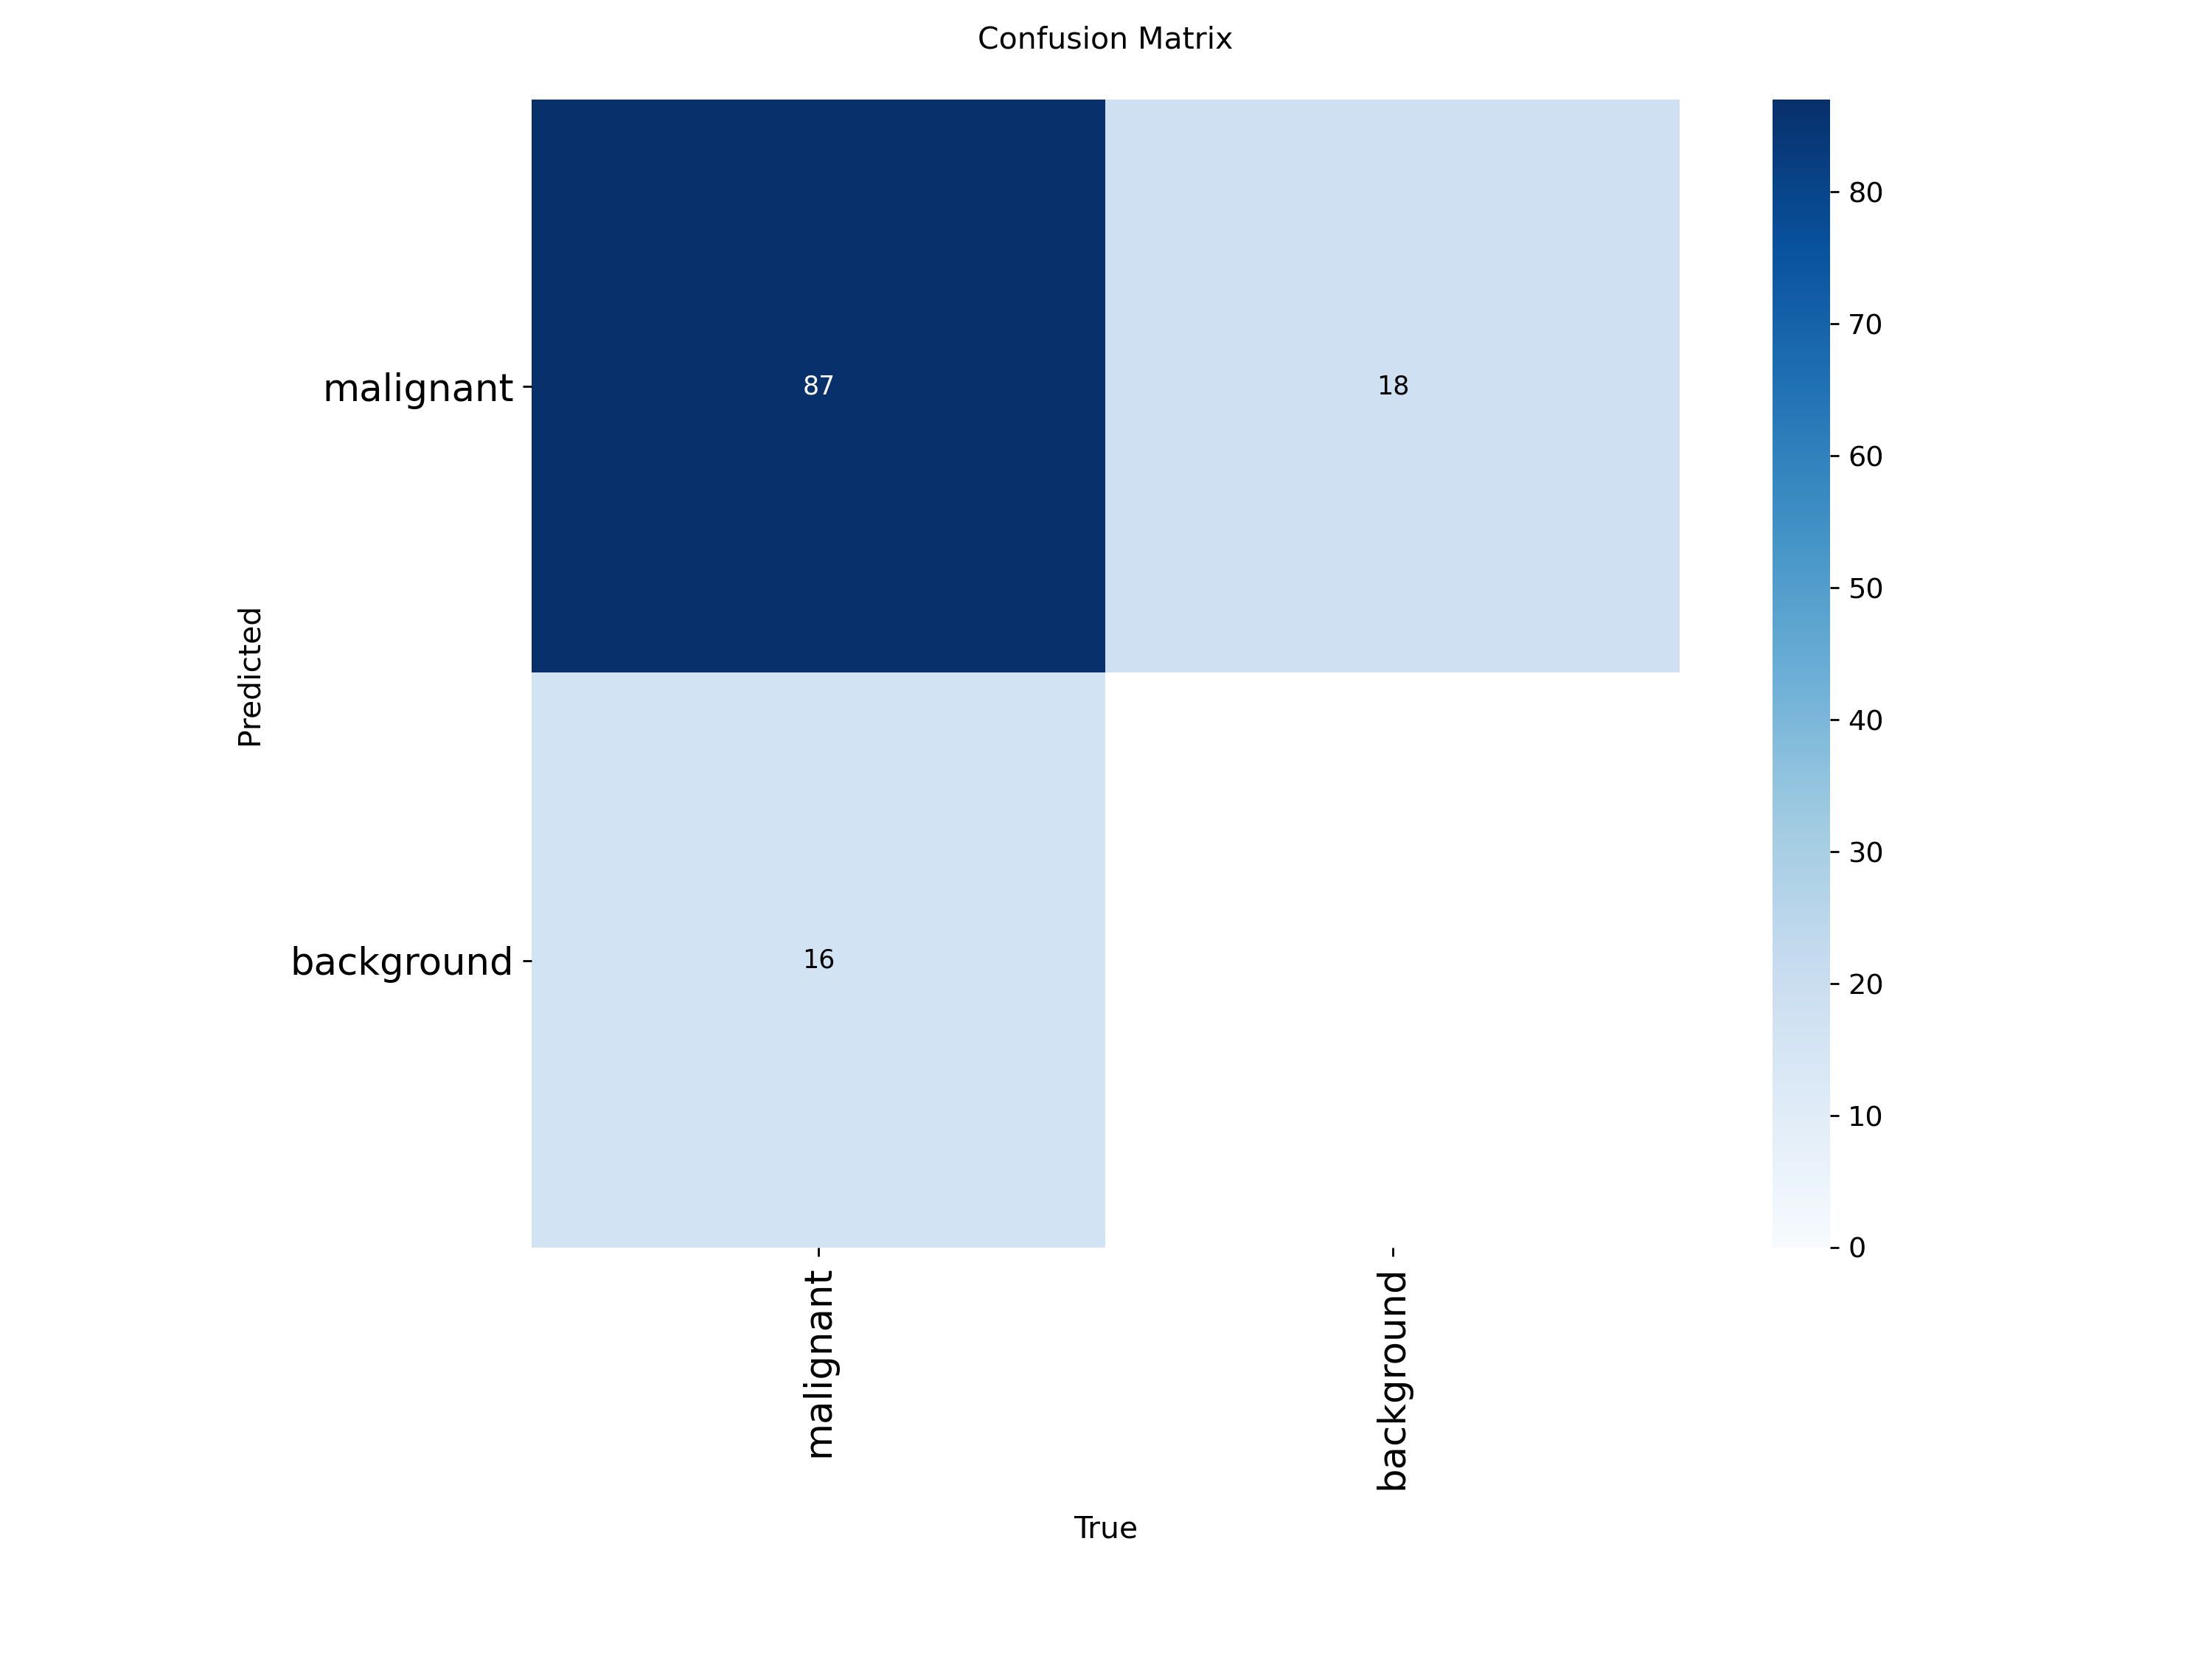

In [48]:
from IPython.display import Image

Image(
filename="/content/runs/detect/train-5/confusion_matrix.png"
)

In [18]:
metrics=model.val()

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,436,161 parameters, 0 gradients, 3.3 GFLOPs
train: /content/skin_classification/train... found 613 images in 1 classes ✅ 
val: /content/skin_classification/valid... found 99 images in 1 classes ✅ 
test: /content/skin_classification/test... found 47 images in 1 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1122.4±366.9 MB/s, size: 23.5 KB)
val: Scanning /content/skin_classification/valid... 99 images, 0 corrupt: 100% ━━━━━━━━━━━━ 99/99 31.9Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 7/7 8.4it/s 0.8s
                   all          1          1
Speed: 0.4ms preprocess, 2.6ms inference, 0.1ms loss, 0.1ms postprocess per image
Results saved to /content/runs/classify/val


In [19]:
print(metrics)

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a9a08846420>
curves: []
curves_results: []
fitness: 1.0
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 1.0, 'metrics/accuracy_top5': 1.0, 'fitness': 1.0}
save_dir: PosixPath('/content/runs/classify/val')
speed: {'preprocess': 0.38799191919807907, 'inference': 2.6133348383752097, 'loss': 0.05838805049683692, 'postprocess': 0.09402601009618722}
top1: 1.0
top5: 1.0


In [20]:
best_model=YOLO(
"/content/runs/classify/train/weights/best.pt"
)

In [49]:
import random
import os


test_folder="/content/skin-1/test/images"


# get all test images
images = os.listdir(test_folder)


# choose random image
img = random.choice(images)


test_image = test_folder + "/" + img


print(test_image)

/content/skin-1/test/images/malignant-399-_jpg.rf.ab9b7c663e1283dc0ff24ac71020f1ee.jpg


In [50]:
results = model.predict(
    source=test_image,
    save=True
)


image 1/1 /content/skin-1/test/images/malignant-399-_jpg.rf.ab9b7c663e1283dc0ff24ac71020f1ee.jpg: 640x640 1 malignant, 8.0ms
Speed: 3.6ms preprocess, 8.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


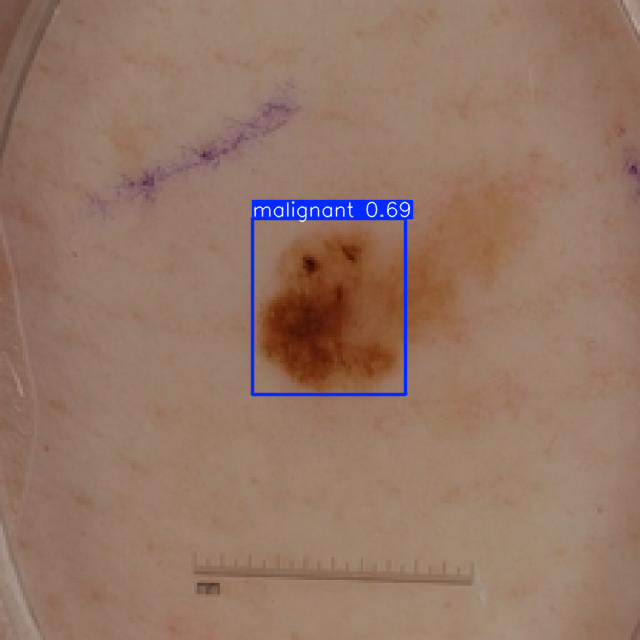

In [51]:
results[0].show()

In [53]:
id="det_pred"
result = results[0]


for box in result.boxes:

    class_id = int(box.cls[0])

    confidence = float(box.conf[0])


    predicted = result.names[class_id]


    print("Prediction:", predicted)
    print("Confidence:", confidence)

Prediction: malignant
Confidence: 0.6934099793434143


The YOLOv8 object detection model was successfully trained on the skin lesion image dataset. The model learned visual features to identify and localize malignant skin lesion regions using bounding box predictions.

The model performance was evaluated using detection metrics such as precision, recall, mAP50, and mAP50-95 along with the confusion matrix.

The project demonstrated the complete computer vision workflow:
dataset preparation → YOLOv8 model training → performance evaluation → object detection on unseen test images.

##Testing

In [57]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train-5/weights/best.pt")

print("Model loaded")
print("Task:", model.task)

Model loaded
Task: detect


In [58]:
import random
import os


test_folder="/content/skin-1/test/images"


images=os.listdir(test_folder)


image=random.choice(images)


test_image=test_folder+"/"+image


print(test_image)

/content/skin-1/test/images/malignant-381-_jpg.rf.1a7b9d28a5105fd9f50c407eb5976484.jpg


In [59]:
results = model.predict(
    source=test_image,
    conf=0.5
)


image 1/1 /content/skin-1/test/images/malignant-381-_jpg.rf.1a7b9d28a5105fd9f50c407eb5976484.jpg: 640x640 (no detections), 8.2ms
Speed: 2.1ms preprocess, 8.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


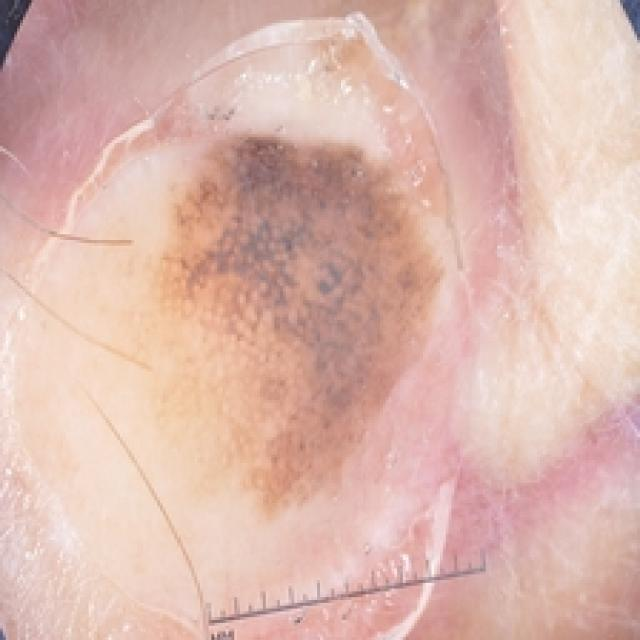

In [60]:
results[0].show()

In [66]:
result = results[0]


for box in result.boxes:

    class_id = int(box.cls[0])

    confidence = float(box.conf[0])


    class_name = result.names[class_id]

    print("Class:", class_name)
    print("Confidence:", round(confidence,3))

In [79]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train-5/weights/best.pt")


results = model.predict(
    source="/content/skin-1/test/images",
    save=True,
    name="all_test_predictions"
)


image 1/47 /content/skin-1/test/images/malignant-140-_jpg.rf.1e5e6e46af0b74c18e5c5bf4f2f37c94.jpg: 640x640 1 malignant, 8.2ms
image 2/47 /content/skin-1/test/images/malignant-141-_jpg.rf.b0f3f26a0554e05436bc99529e188469.jpg: 640x640 2 malignants, 7.2ms
image 3/47 /content/skin-1/test/images/malignant-152-_jpg.rf.b638bf7854567a14b1315c6c4995a9f9.jpg: 640x640 1 malignant, 7.2ms
image 4/47 /content/skin-1/test/images/malignant-16-_jpg.rf.dcaecc32fcd4428cb19b0886e5d02ff1.jpg: 640x640 1 malignant, 7.2ms
image 5/47 /content/skin-1/test/images/malignant-17-_jpg.rf.02a4fe1b02da67d8166a898aae58943d.jpg: 640x640 (no detections), 7.2ms
image 6/47 /content/skin-1/test/images/malignant-172-_jpg.rf.cb0e4e0607df06f4f6a5842194641bda.jpg: 640x640 1 malignant, 7.2ms
image 7/47 /content/skin-1/test/images/malignant-180-_jpg.rf.907c0949684796383d1c21a26c376204.jpg: 640x640 1 malignant, 7.2ms
image 8/47 /content/skin-1/test/images/malignant-182-_jpg.rf.2e66ae96cab600f056e4fe12f942703f.jpg: 640x640 1 malig

In [81]:
import glob

pred_images = glob.glob(
    "/content/runs/detect/all_test_predictions/*"
)

print(len(pred_images))

47


/content/runs/detect/all_test_predictions/malignant-180-_jpg.rf.907c0949684796383d1c21a26c376204.jpg


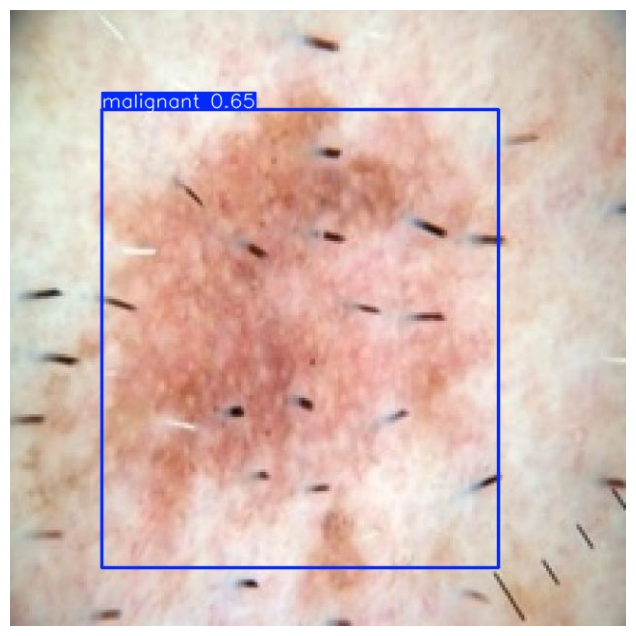

In [89]:
import random
from PIL import Image
import matplotlib.pyplot as plt


img_path = random.choice(pred_images)

print(img_path)


img = Image.open(img_path)


plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()